In [1]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt

protocol_times=[10,20,50,100,1000,2000,3000,5000,8000,10000,12000]

opt_dict={}
opt_dict_new={}

In [2]:
# serialization of process tensor (optional)
import dill

for t_prot in protocol_times:
# processtensor_simplemodel
    file_name1='results/constant_control/{0}ps/optimization_simplemodel_{0}ps'.format(t_prot)
    with open(file_name1,'rb') as f:
        opt_dict[t_prot]=dill.load(f)

10
20
50
100
1000
2000
3000
5000
8000
10000
12000


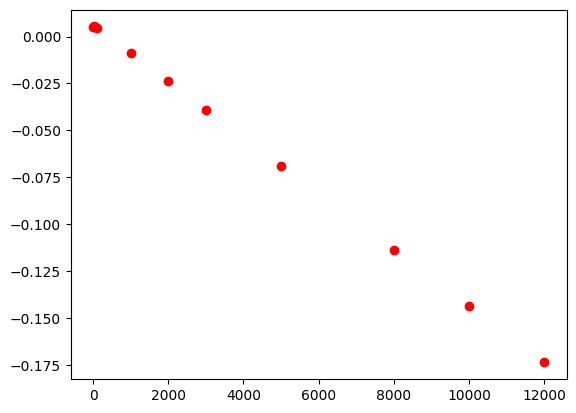

In [3]:
# plotting final heat values

for t_prot in opt_dict:
    print(t_prot)
    try:
        plt.plot(t_prot,opt_dict[t_prot]['result'].fun,'ro')
    except:
        plt.plot(t_prot,opt_dict[t_prot].fun,'ro')
plt.show()


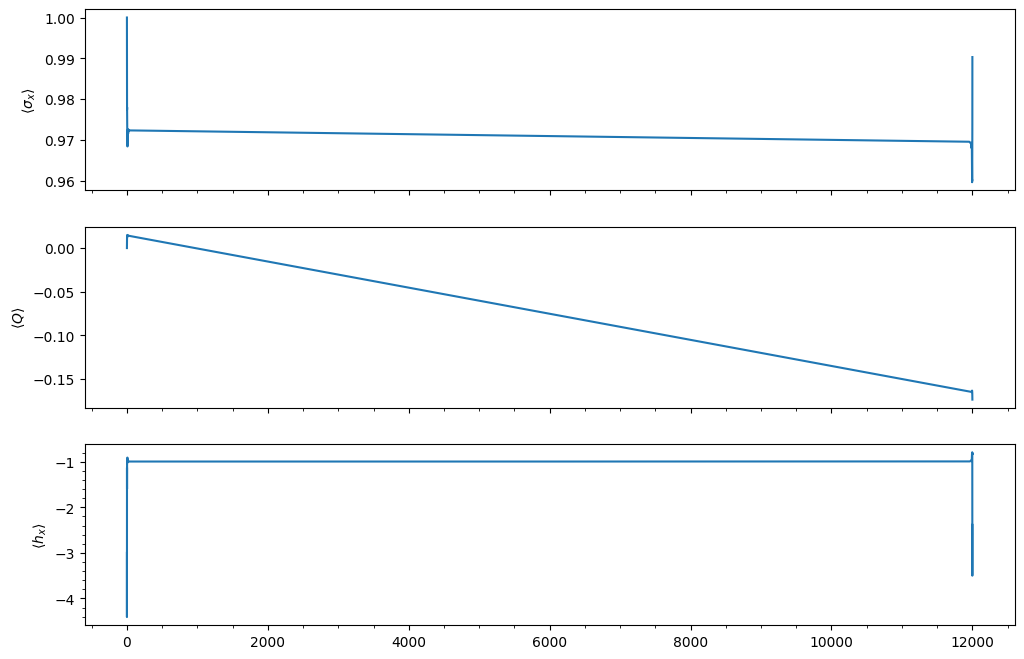

In [11]:
fig=plt.figure(figsize=(12,8))
gs=fig.add_gridspec(3,hspace=0.2)
axs=gs.subplots(sharex=True)
t,sx=opt_dict[12000]['fidelitygrad']['dynamics'].expectations(op.sigma('x'),real=True)
t,sy=opt_dict[12000]['fidelitygrad']['dynamics'].expectations(op.sigma('y'),real=True)
t,sz=opt_dict[12000]['fidelitygrad']['dynamics'].expectations(op.sigma('z'),real=True)
heat_t=opt_dict[12000]['log'][-1]['full heats']
opt_control=opt_dict[12000]['result'].x

axs[0].plot(t,sx)
axs[0].set_ylabel(r'$\langle \sigma_x \rangle$')


axs[1].plot(t,heat_t)
axs[1].set_ylabel(r'$\langle Q \rangle$')

axs[2].plot(t[:-1],opt_control)
axs[2].set_ylabel(r'$\langle h_x \rangle$')

axs[2].minorticks_on()
#axs[2].set_xticks(np.arange(0,10,step=0.25))

(0.0, 10.0)

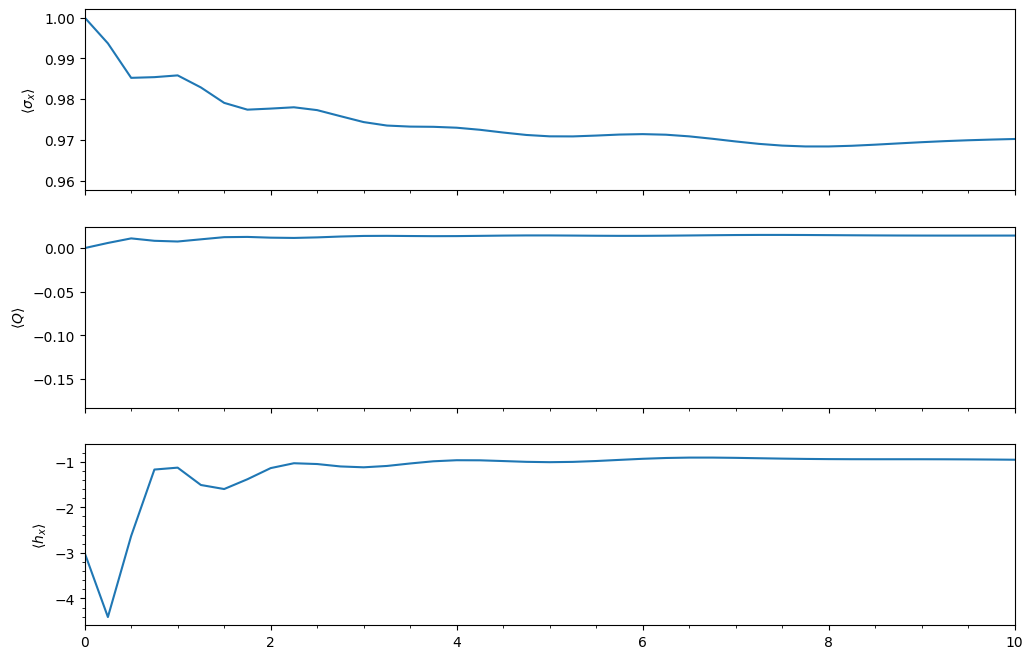

In [6]:
fig=plt.figure(figsize=(12,8))
gs=fig.add_gridspec(3,hspace=0.2)
axs=gs.subplots(sharex=True)
t,sx=opt_dict[12000]['fidelitygrad']['dynamics'].expectations(op.sigma('x'),real=True)
heat_t=opt_dict[12000]['log'][-1]['full heats']
opt_control=opt_dict[12000]['result'].x

axs[0].plot(t,sx)
axs[0].set_ylabel(r'$\langle \sigma_x \rangle$')


axs[1].plot(t,heat_t)
axs[1].set_ylabel(r'$\langle Q \rangle$')

axs[2].plot(t[:-1],opt_control)
axs[2].set_ylabel(r'$\langle h_x \rangle$')

axs[2].minorticks_on()
#axs[2].set_xticks(np.arange(0,10,step=0.25))
axs[2].set_xlim(0,10)

In [5]:
np.arange(0,12000,step=0.25)

array([0.000000e+00, 2.500000e-01, 5.000000e-01, ..., 1.199925e+04,
       1.199950e+04, 1.199975e+04])